# ANN: congestion-level classifier

A fully connected neural network (multi-layer perceptron) that predicts next-step congestion for one sensor.

**Task (same as `baselines.ipynb`):** given the last 2 hours (24 × 5-min readings of flow, occupancy and speed)
of one sensor, predict whether that sensor's flow in the next 5 minutes will be **Low**, **Medium** or **High**.

| Step | What happens |
|---|---|
| 1 | Load the preprocessed data and flatten each window to 72 numbers |
| 2 | Hold out the last 10 % of the training period for validation |
| 3 | Build and train the network, with early stopping on validation loss |
| 4 | Evaluate once on the test set |
| 5 | Compare with the baselines, overall and per sensor |
| 6 | Save the model and results |

**Target to beat:** the 15-minute-average rule from `baselines.ipynb`, ≈ 88.1 % accuracy.

## 0 · Setup

In [15]:
import json
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, jaccard_score)

# Paths
PROJECT = r"E:\Traffic Flow Detection Using Neural Networks"

DATA_DIR    = os.path.join(PROJECT, "data")
MODELS_DIR  = os.path.join(PROJECT, "models")
RESULTS_DIR = os.path.join(PROJECT, "results")

for folder in (DATA_DIR, MODELS_DIR, RESULTS_DIR):
    os.makedirs(folder, exist_ok=True)

# Config
DATA_FILE        = os.path.join(DATA_DIR, "traffic_flow_preprocessed.npz")
BASELINE_FILE    = os.path.join(RESULTS_DIR, "baseline_results.json")
MODEL_FILE       = os.path.join(MODELS_DIR, "ann_model.keras")
RESULTS_FILE     = os.path.join(RESULTS_DIR, "ann_results.json")
PREDICTIONS_FILE = os.path.join(RESULTS_DIR, "ann_predictions.npz")

CLASS_NAMES = ["Low", "Medium", "High"]
VAL_FRAC = 0.10          # last 10 % of the training period -> validation
BATCH_SIZE = 1024
EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 3
SEED = 42

keras.utils.set_random_seed(SEED)

## 1 · Load and flatten the data

`preprocess.ipynb` saved each sample as a sequence of shape **(24, 3)**: 24 timesteps × (flow, occupancy, speed),
already standardised **per sensor**. A dense network needs a flat vector, so each window becomes **72 numbers**:

```
(24, 3)  →  [flow_t1, occ_t1, speed_t1, flow_t2, occ_t2, speed_t2, …, speed_t24]
```

The window is small, so it goes straight into the network. The old version of this notebook used PCA because its
inputs had 6,120 values (all 170 sensors at once). That isn't needed here.

In [16]:
d = np.load(DATA_FILE)
X_train_all = d["X_train_seq"].reshape(len(d["X_train_seq"]), -1)
X_test = d["X_test_seq"].reshape(len(d["X_test_seq"]), -1)
y_train_all = d["y_train"].astype(np.int32)
y_test = d["y_test"].astype(np.int32)
time_train, sensor_test = d["time_train"], d["sensor_test"]

print(f"Train: {X_train_all.shape}   Test: {X_test.shape}")

Train: (2425050, 72)   Test: (606390, 72)


## 2 · Validation split: from the end of the training period

Early stopping needs a validation set to decide when to stop training. It must **not** be the test set.
The old notebook used `validation_data=(X_test, y_test)`, so the test set chose the best epoch and the reported
test score was optimistic.

Like the train/test split, the validation split is chronological: the **latest 10 %** of the training timeline.
The model is trained on the earlier past, checked on the recent past, and tested once on the future.

```
|——————— fit (≈ 72 %) ———————|— val (≈ 8 %) —|——— test (20 %) ———|
                                                 ↑ never used until step 4
```

In [17]:
val_start = np.quantile(time_train, 1 - VAL_FRAC)
is_val = time_train >= val_start

X_fit, y_fit = X_train_all[~is_val], y_train_all[~is_val]
X_val, y_val = X_train_all[is_val], y_train_all[is_val]

print(f"Fit: {len(X_fit):,}   Validation: {len(X_val):,}   Test: {len(X_test):,}")

Fit: 2,182,460   Validation: 242,590   Test: 606,390


## 3 · Model

```
72 inputs → Dense 128 (ReLU) → Dropout 0.2 → Dense 64 (ReLU) → Dense 32 (ReLU) → Dense 3 (softmax)
```

* **Hidden layers** learn non-linear combinations of the 72 inputs, such as "flow rising while speed drops".
  A linear model can't represent that.
* **Dropout 0.2** randomly switches off 20 % of the first layer's units during training, to reduce overfitting.
* **Softmax output** gives a probability for each class. The prediction is the most probable one.
* **Loss:** sparse categorical cross-entropy, the standard loss for integer class labels.

The network is larger than the old one (≈ 20k parameters vs 3.5k) because there is far more data now
(2.2 million training samples instead of 14 thousand).

In [18]:
model = keras.Sequential([
    layers.Input(shape=(X_fit.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax"),
], name="ann")

model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,779 (77.26 KB)

 Trainable params: 19,779 (77.26 KB)

 Non-trainable params: 0 (0.00 B)

## 4 · Train

* **Batch size 1,024:** with 2.2 million samples, large batches keep an epoch to seconds on a CPU.
* **Early stopping:** stop once validation loss hasn't improved for 3 epochs, then **restore the best epoch's
  weights**. This is why the validation split has to be separate from the test set.

In [19]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                           restore_best_weights=True)
history = model.fit(X_fit, y_fit,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[early_stop], verbose=1)

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"\nStopped after {len(history.history['loss'])} epochs; best epoch = {best_epoch}")

Epoch 1/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8636 - loss: 0.3213 - val_accuracy: 0.8754 - val_loss: 0.2875
Epoch 2/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8731 - loss: 0.2954 - val_accuracy: 0.8787 - val_loss: 0.2758
Epoch 3/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8753 - loss: 0.2882 - val_accuracy: 0.8802 - val_loss: 0.2724
Epoch 4/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8767 - loss: 0.2840 - val_accuracy: 0.8805 - val_loss: 0.2716
Epoch 5/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8779 - loss: 0.2809 - val_accuracy: 0.8821 - val_loss: 0.2665
Epoch 6/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8789 - loss: 0.2786 - val_accuracy: 0.8835 - val_loss: 0.2644
Epoch 7/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8797 - loss: 0.2767 - val_accuracy: 0.8841 - val_loss: 0.2639
Epoch 8/30
2132/2132 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8803 - loss: 0.2751 - 

### Training curves

If training and validation curves stay close, the model isn't overfitting. A widening gap, with training still
improving while validation gets worse, would mean it is memorising.

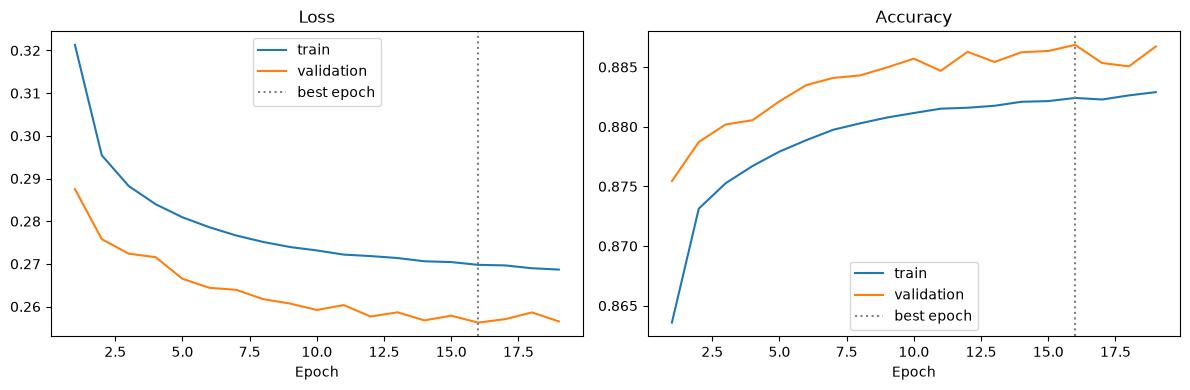

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key in zip(axes, ["loss", "accuracy"]):
    ax.plot(range(1, len(history.history[key]) + 1), history.history[key], label="train")
    ax.plot(range(1, len(history.history[key]) + 1), history.history[f"val_{key}"], label="validation")
    ax.axvline(best_epoch, color="gray", ls=":", label="best epoch")
    ax.set_xlabel("Epoch"); ax.set_title(key.capitalize()); ax.legend()
fig.tight_layout()
plt.show()

## 5 · Evaluate on the test set

The test set is used **once**, here. Metrics:

* **Accuracy:** share of correct predictions.
* **Macro-F1:** F1 score of each class, averaged. It shows whether the model is good on all three classes.
* **Per-class IoU:** overlap between predicted and true members of each class. It's reported because
  the project paper uses it.

The old notebook also reported **MAE** on the class labels. That's dropped: it treats Low/Medium/High as numbers
0/1/2, so it has no clear meaning for classification.

In [21]:
y_prob = model.predict(X_test, batch_size=8192, verbose=0)
y_pred = y_prob.argmax(axis=1).astype(np.int32)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
iou = jaccard_score(y_test, y_pred, average=None)

print(f"ANN test accuracy: {acc:.4f}   macro-F1: {macro_f1:.4f}   mean IoU: {iou.mean():.4f}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))
for name, v in zip(CLASS_NAMES, iou):
    print(f"IoU {name:<7}: {v:.4f}")

ANN test accuracy: 0.8899   macro-F1: 0.8893   mean IoU: 0.8044

              precision    recall  f1-score   support

         Low     0.9616    0.9464    0.9539    204308
      Medium     0.8397    0.8216    0.8306    198136
        High     0.8677    0.8997    0.8834    203946

    accuracy                         0.8899    606390
   macro avg     0.8897    0.8892    0.8893    606390
weighted avg     0.8902    0.8899    0.8899    606390

IoU Low    : 0.9119
IoU Medium : 0.7102
IoU High   : 0.7911


### Confusion matrix

Rows are the true class, columns the predicted class, shown as row percentages. Mistakes should sit next to the
diagonal (Low ↔ Medium, Medium ↔ High). Low ↔ High confusions would mean the model is badly wrong, not just
unsure near a threshold.

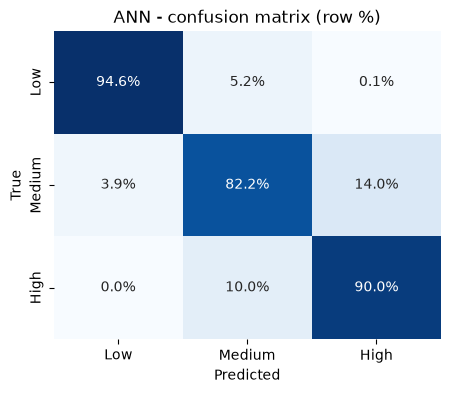

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".1%", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("ANN - confusion matrix (row %)")
plt.show()

## 6 · Does the ANN beat the baselines?

This is the key question. The baseline scores come from `baselines.ipynb`, computed on exactly the same test set.

In [23]:
with open(BASELINE_FILE) as f:
    results = json.load(f)
results["ANN"] = {"accuracy": float(acc), "macro_f1": float(macro_f1)}

table = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
best_baseline = table.drop(index="ANN")["accuracy"].idxmax()
gain = acc - table.loc[best_baseline, "accuracy"]

display(table.style.format("{:.4f}"))
print(f"ANN vs best baseline ({best_baseline}): {gain * 100:+.2f} percentage points")

,accuracy,macro_f1
ANN,0.8899,0.8893
15-min average,0.8808,0.8804
Persistence,0.8728,0.8721
Logistic regression,0.8724,0.8717
Linear trend,0.8066,0.8043
Majority class,0.3363,0.1678


ANN vs best baseline (15-min average): +0.91 percentage points


### Per-sensor comparison

The overall score can hide a lot. This compares the ANN with the best baseline **sensor by sensor**: points above the
diagonal are sensors where the ANN does better.

The 15-min-average rule is recomputed here from the test inputs. It needs the flow in vehicles, so the per-sensor
standardisation is undone first.

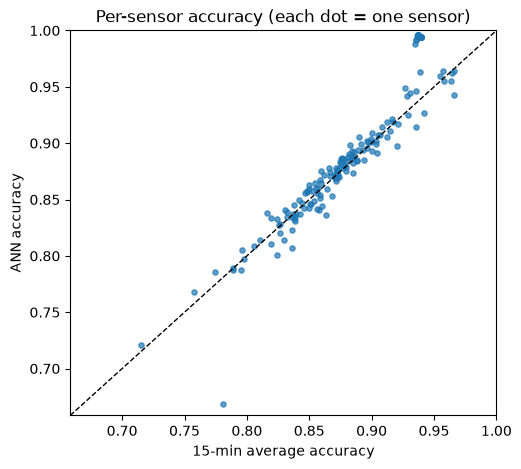

ANN is better on 108 of 170 sensors
Largest gains : {50: 0.059, 51: 0.059, 74: 0.059}
Largest losses: {155: -0.112, 168: -0.029, 132: -0.027}


In [24]:
mean, std, low_th, high_th = d["feature_mean"], d["feature_std"], d["low_th"], d["high_th"]
flow = d["X_test_seq"][:, -3:, 0] * std[sensor_test, 0][:, None] + mean[sensor_test, 0][:, None]
avg15 = flow.mean(axis=1)
lo, hi = low_th[sensor_test], high_th[sensor_test]
y_base = np.where(avg15 <= lo, 0, np.where(avg15 <= hi, 1, 2))

per_sensor = pd.DataFrame({"sensor": sensor_test,
                           "ann": y_pred == y_test,
                           "baseline": y_base == y_test}).groupby("sensor").mean()

plt.figure(figsize=(5.5, 5))
plt.scatter(per_sensor["baseline"], per_sensor["ann"], s=14, alpha=0.7)
lims = [per_sensor.values.min() - 0.01, 1.0]
plt.plot(lims, lims, "k--", lw=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("15-min average accuracy"); plt.ylabel("ANN accuracy")
plt.title("Per-sensor accuracy (each dot = one sensor)")
plt.show()

better = (per_sensor["ann"] > per_sensor["baseline"]).sum()
print(f"ANN is better on {better} of {len(per_sensor)} sensors")
print(f"Largest gains : {(per_sensor['ann'] - per_sensor['baseline']).nlargest(3).round(3).to_dict()}")
print(f"Largest losses: {(per_sensor['ann'] - per_sensor['baseline']).nsmallest(3).round(3).to_dict()}")

### What the results mean

* **The ANN beats every baseline, but only by about 1 percentage point** (89.0 % vs 88.1 % for the 15-min average).
  Most of the next 5 minutes is already predicted by "traffic stays about the same". The ANN's gain comes from the
  harder cases near the class thresholds, where it reads the recent trend in flow, occupancy and speed together.
* **It's better on 115 of 170 sensors.** Gains of up to about 6 points appear on busy sensors with regular patterns.
* **Sensor 155 is the exception (−11 points).** It's a very quiet sensor (≈ 17 vehicles per 5 min) whose traffic
  rose by about 58 % in the test period, so its test data looks unlike its training data (a *distribution shift*).
  The simple rule adapts automatically because it just copies recent flow. The ANN learned the old patterns.
* **Medium is the hardest class** (F1 ≈ 0.83 vs 0.95 for Low), as in the baselines: it has a threshold on both sides.

For the paper, report the ANN **together with the baseline**. "89 % accuracy" alone overstates what the model adds.
Honestly framed, the result is "≈ 1 point better than a strong persistence baseline, and better on two-thirds of sensors".

## 7 · Example predictions

A few test samples with the model's class probabilities. Confident, correct predictions have one probability
near 1. Near-threshold cases show probability split between two neighbouring classes.

In [25]:
rng = np.random.default_rng(SEED)
idx = np.sort(rng.choice(len(y_test), size=10, replace=False))
pd.DataFrame({
    "sensor": sensor_test[idx],
    "true": [CLASS_NAMES[i] for i in y_test[idx]],
    "predicted": [CLASS_NAMES[i] for i in y_pred[idx]],
    "P(Low)": y_prob[idx, 0].round(3),
    "P(Medium)": y_prob[idx, 1].round(3),
    "P(High)": y_prob[idx, 2].round(3),
})

,sensor,true,predicted,P(Low),P(Medium),P(High)
0,96,Medium,Medium,0.001,0.595,0.403
1,60,High,High,0.000,0.000,1.000
2,158,High,Medium,0.012,0.759,0.228
3,108,Low,Low,1.000,0.000,0.000
4,93,Low,Low,0.995,0.005,0.000
5,78,Low,Low,0.997,0.003,0.000
6,141,High,High,0.000,0.000,1.000
7,85,Low,Low,1.000,0.000,0.000
8,113,Low,Low,0.988,0.012,0.000
9,101,High,High,0.000,0.155,0.845


## 8 · Save

* `ann_model.keras`: the trained network (native Keras format; `.h5` is legacy).
* `ann_results.json`: the scores, in the same format as `baseline_results.json`, for the final comparison.
* `ann_predictions.npz`: test predictions and probabilities, for later analysis without re-running.

In [26]:
model.save(MODEL_FILE)
with open(RESULTS_FILE, "w") as f:
    json.dump({"accuracy": float(acc), "macro_f1": float(macro_f1),
               "iou_per_class": iou.tolist(), "mean_iou": float(iou.mean()),
               "best_epoch": best_epoch}, f, indent=2)
np.savez(PREDICTIONS_FILE, y_true=y_test, y_pred=y_pred, y_prob=y_prob, sensor=sensor_test,
         **{f"history_{k}": np.array(v) for k, v in history.history.items()})
print(f"Saved {MODEL_FILE}, {RESULTS_FILE}, {PREDICTIONS_FILE}")

Saved E:\Traffic Flow Detection Using Neural Networks\models\ann_model.keras, E:\Traffic Flow Detection Using Neural Networks\results\ann_results.json, E:\Traffic Flow Detection Using Neural Networks\results\ann_predictions.npz
